# 05 — Final Evaluation & Statistical Analysis

**Goal**: Load experimental results and produce dissertation-ready figures and statistics.

Topics:
1. Load results from experiments (baselines, GA, hybrid)
2. Aggregate into long-form DataFrame
3. Summary statistics and box plots per instance config
4. Wilcoxon signed-rank tests (pairwise comparisons)
5. Sensitivity analysis: re-normalise composite across alpha values
6. Export results as LaTeX and CSV

In [1]:
import sys, os

# Ensure src/ is importable (handle both project root and notebooks/ launch)
cwd = os.getcwd()
if cwd.endswith('/notebooks') or cwd.endswith('\\notebooks'):
    root = os.path.dirname(cwd)
else:
    root = cwd
if root not in sys.path:
    sys.path.insert(0, root)

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import pingouin as pg
from scipy import stats
from src.instance_generator import INSTANCE_CONFIGS
from src.evaluator import estimate_scales
sns.set_theme(style="whitegrid")
os.makedirs(os.path.join(root, "figures"), exist_ok=True)
print("✓ Imports complete")

✓ Imports complete


## 1. Load Results

In [2]:
# Check if results exist
results_dir = Path(root) / "results" / "raw"
baselines_file = results_dir / f"baselines_{PROFILE}.json"
ga_file = results_dir / f"ga_{PROFILE}.json"
hybrid_file = results_dir / f"hybrid_{PROFILE}.json"

print("Checking for result files...")
print(f"Looking in: {results_dir}")
files_exist = {
    "baselines": baselines_file.exists(),
    "ga": ga_file.exists(),
    "hybrid": hybrid_file.exists()
}
print(files_exist)

# Load available results
results_data = {}

if files_exist["baselines"]:
    with open(baselines_file) as f:
        results_data["baselines"] = json.load(f)
    print(f"✓ Loaded baselines.json ({len(results_data['baselines'])} configs)")
else:
    print("⚠ baselines.json not found (run experiments/run_baselines.py)")
    results_data["baselines"] = None

if files_exist["ga"]:
    with open(ga_file) as f:
        results_data["ga"] = json.load(f)
    print(f"✓ Loaded ga.json ({len(results_data['ga'])} configs)")
else:
    print("⚠ ga.json not found (run experiments/run_ga.py)")
    results_data["ga"] = None

if files_exist["hybrid"]:
    with open(hybrid_file) as f:
        results_data["hybrid"] = json.load(f)
    print(f"✓ Loaded hybrid.json ({len(results_data['hybrid'])} configs)")
else:
    print("⚠ hybrid.json not found (run experiments/run_hybrid.py)")
    results_data["hybrid"] = None

Checking for result files...
Looking in: /home/dopedino/Documents/Dissertation/results/raw
{'baselines': True, 'ga': True, 'hybrid': True}
✓ Loaded baselines.json (6 configs)
✓ Loaded ga.json (6 configs)
✓ Loaded hybrid.json (6 configs)


In [3]:
# Build long-form DataFrame (defensive: only include loaded results)
print("\nBuilding long-form DataFrame from available results...")
rows = []

if results_data["baselines"]:
    for config, heuristics in results_data["baselines"].items():
        for heuristic_name, entries in heuristics.items():
            method = "SPT" if heuristic_name == "spt" else "NN-Greedy"
            for entry in entries:
                rows.append({
                    "method": method,
                    "config": config,
                    "seed": entry["seed"],
                    "composite": entry["composite"],
                    "weighted_tardiness": entry["weighted_tardiness"],
                    "setup_cost": entry["setup_cost"],
                    "makespan": entry["makespan"]
                })

if results_data["ga"]:
    for config, entries in results_data["ga"].items():
        for entry in entries:
            rows.append({
                "method": "GA",
                "config": config,
                "seed": entry["seed"],
                "composite": entry["composite"],
                "weighted_tardiness": entry["weighted_tardiness"],
                "setup_cost": entry["setup_cost"],
                "makespan": entry["makespan"]
            })

if results_data["hybrid"]:
    for config, entries in results_data["hybrid"].items():
        for entry in entries:
            rows.append({
                "method": "Hybrid",
                "config": config,
                "seed": entry["seed"],
                "composite": entry["composite"],
                "weighted_tardiness": entry["weighted_tardiness"],
                "setup_cost": entry["setup_cost"],
                "makespan": entry["makespan"]
            })

if rows:
    results_df = pd.DataFrame(rows)
    print(f"Created DataFrame with {len(results_df)} rows")
    print(f"Methods: {results_df['method'].unique()}")
    print(f"Configs: {results_df['config'].unique()}")
else:
    print("⚠ No results loaded yet. Run experiments to populate results/raw/*.json")
    results_df = None


Building long-form DataFrame from available results...
Created DataFrame with 720 rows
Methods: <StringArray>
['SPT', 'NN-Greedy', 'GA', 'Hybrid']
Length: 4, dtype: str
Configs: <StringArray>
['small_2m', 'small_3m', 'medium_2m', 'medium_3m', 'large_2m', 'large_3m']
Length: 6, dtype: str


## 2. Summary Statistics

In [4]:
if results_df is not None:
    print("\n=== Summary Statistics by Method × Config ===")
    summary = results_df.groupby(["config", "method"])[["composite", "weighted_tardiness", "setup_cost", "makespan"]].agg(["mean", "std"]).round(3)
    print(summary)
    
    # Overall mean per method
    print("\n=== Overall Mean by Method ===")
    overall = results_df.groupby("method")[["composite", "weighted_tardiness", "setup_cost", "makespan"]].mean().round(3)
    print(overall)
else:
    print("No data to summarise. Run experiments first.")


=== Summary Statistics by Method × Config ===
                    composite        weighted_tardiness          setup_cost  \
                         mean    std               mean      std       mean   
config    method                                                              
large_2m  GA            0.040  0.006             91.027   70.965    235.400   
          Hybrid        0.041  0.005            110.030   90.247    236.538   
          NN-Greedy     0.026  0.003            180.709  140.670    139.664   
          SPT           0.099  0.010              0.000    0.000    598.963   
large_3m  GA            0.037  0.004            105.229   72.854    215.983   
          Hybrid        0.036  0.005            121.227   96.672    211.404   
          NN-Greedy     0.033  0.002             88.203   70.770    190.660   
          SPT           0.098  0.011              0.000    0.000    594.527   
medium_2m GA            0.017  0.006              8.763   17.534     35.682   
     

## 3. Box Plots

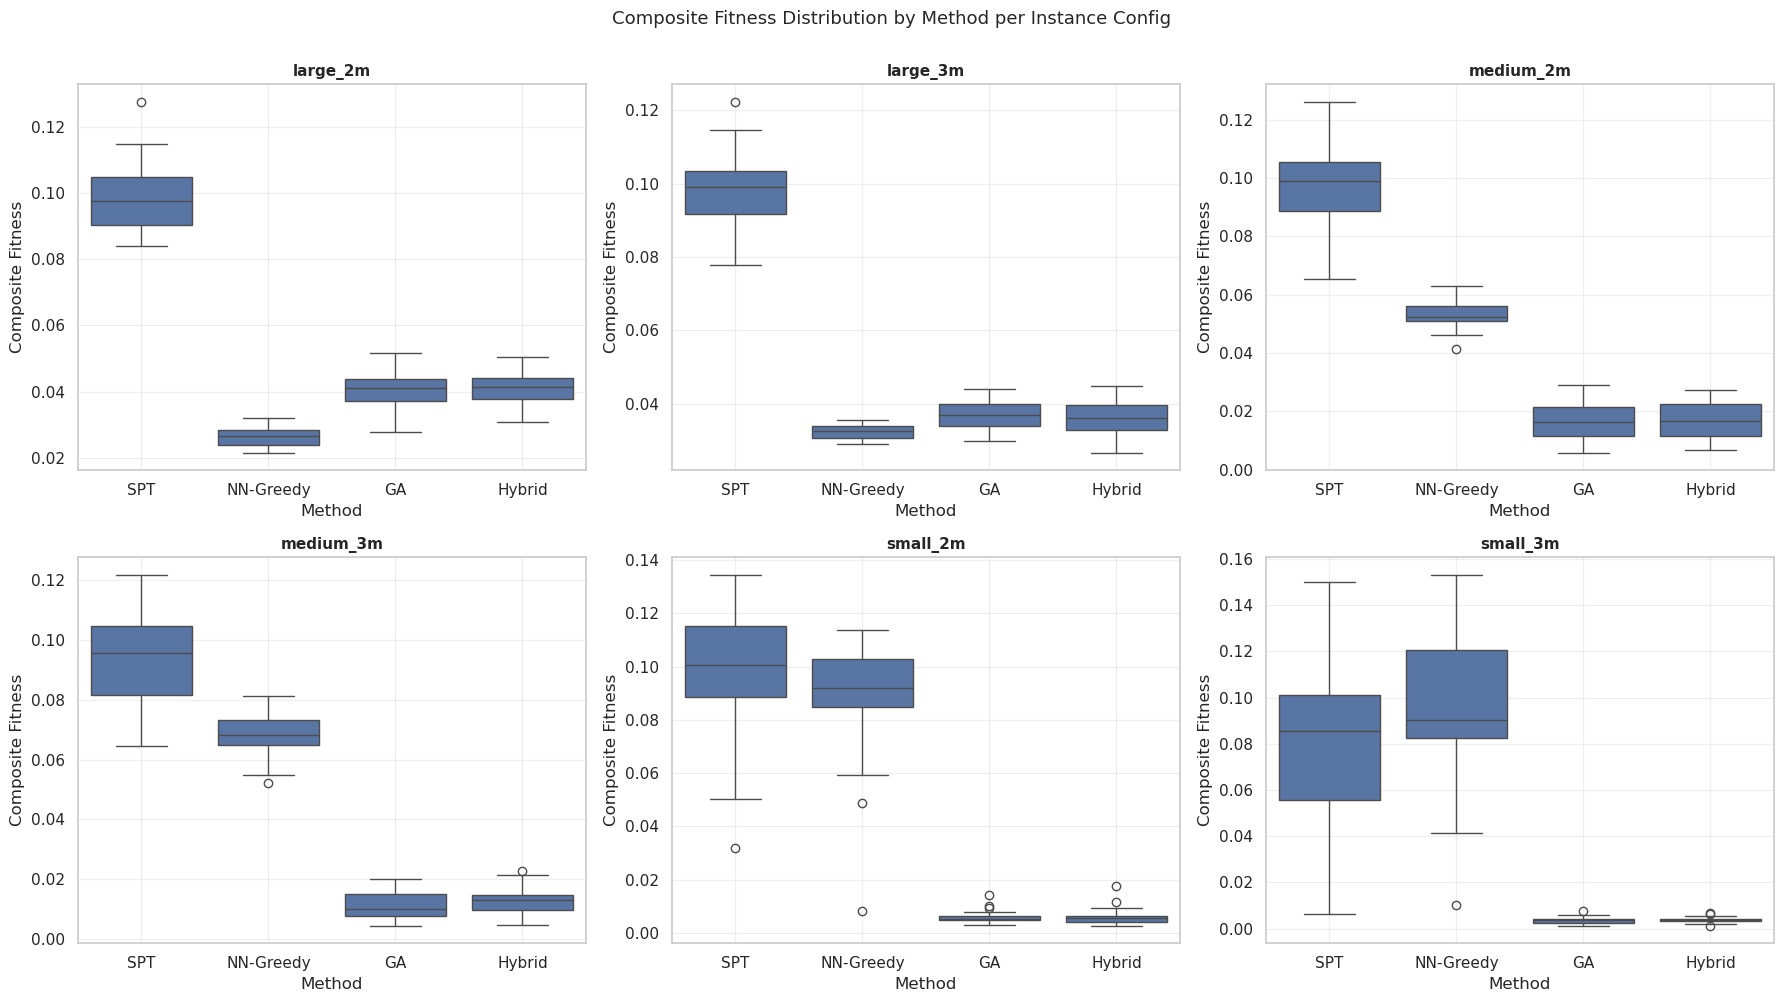

In [5]:
if results_df is not None:
    # Box plots per config (4 methods side-by-side)
    configs = sorted(results_df["config"].unique())
    fig, axes = plt.subplots(3, 4, figsize=(18, 10))
    axes = axes.flatten()
    
    for ax, cfg in zip(axes, configs):
        data = results_df[results_df["config"] == cfg]
        sns.boxplot(data=data, x="method", y="composite", ax=ax)
        ax.set_title(cfg, fontsize=11, fontweight="bold")
        ax.set_xlabel("Method")
        ax.set_ylabel("Composite Fitness (lower is better)")
        ax.grid(True, alpha=0.3)
    
    fig.suptitle("Composite Fitness Distribution by Method per Instance Config [lower is better]", fontsize=13, y=1.00)
    plt.tight_layout()
    plt.savefig(os.path.join(root, "figures/05_boxplots_composite.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No data to plot.")

## 4. Wilcoxon Signed-Rank Tests

In [6]:
if results_df is not None and len(results_df["method"].unique()) > 1:
    print("\n=== Wilcoxon Signed-Rank Tests (pairwise) ===")
    methods = sorted(results_df["method"].unique())
    configs = sorted(results_df["config"].unique())
    
    test_results = []
    
    for cfg in configs:
        cfg_data = results_df[results_df["config"] == cfg]
        print(f"\n{cfg}:")
        
        for i, m1 in enumerate(methods):
            for m2 in methods[i+1:]:
                v1 = cfg_data[cfg_data["method"] == m1]["composite"].values
                v2 = cfg_data[cfg_data["method"] == m2]["composite"].values
                
                if len(v1) > 0 and len(v2) > 0:
                    # Wilcoxon signed-rank test
                    stat, p_value = stats.wilcoxon(v1, v2)
                    mean_diff = np.mean(v1) - np.mean(v2)
                    effect = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
                    
                    print(f"  {m1} vs {m2}: p={p_value:.4f} {effect}, Δmean={mean_diff:.3f}")
                    test_results.append({
                        "config": cfg,
                        "comparison": f"{m1} vs {m2}",
                        "p_value": p_value,
                        "mean_diff": mean_diff,
                        "significant": p_value < 0.05
                    })
    
    if test_results:
        test_df = pd.DataFrame(test_results)
        print("\n=== Test Summary Table ===")
        print(test_df.to_string(index=False))
else:
    print("Insufficient methods or data for Wilcoxon tests.")


=== Wilcoxon Signed-Rank Tests (pairwise) ===

large_2m:
  GA vs Hybrid: p=0.5838 ns, Δmean=-0.001
  GA vs NN-Greedy: p=0.0000 ***, Δmean=0.014
  GA vs SPT: p=0.0000 ***, Δmean=-0.058
  Hybrid vs NN-Greedy: p=0.0000 ***, Δmean=0.015
  Hybrid vs SPT: p=0.0000 ***, Δmean=-0.058
  NN-Greedy vs SPT: p=0.0000 ***, Δmean=-0.072

large_3m:
  GA vs Hybrid: p=0.9838 ns, Δmean=0.001
  GA vs NN-Greedy: p=0.0001 ***, Δmean=0.004
  GA vs SPT: p=0.0000 ***, Δmean=-0.061
  Hybrid vs NN-Greedy: p=0.0001 ***, Δmean=0.004
  Hybrid vs SPT: p=0.0000 ***, Δmean=-0.062
  NN-Greedy vs SPT: p=0.0000 ***, Δmean=-0.065

medium_2m:
  GA vs Hybrid: p=0.8872 ns, Δmean=-0.000
  GA vs NN-Greedy: p=0.0000 ***, Δmean=-0.036
  GA vs SPT: p=0.0000 ***, Δmean=-0.081
  Hybrid vs NN-Greedy: p=0.0000 ***, Δmean=-0.036
  Hybrid vs SPT: p=0.0000 ***, Δmean=-0.080
  NN-Greedy vs SPT: p=0.0000 ***, Δmean=-0.044

medium_3m:
  GA vs Hybrid: p=0.1772 ns, Δmean=-0.002
  GA vs NN-Greedy: p=0.0000 ***, Δmean=-0.057
  GA vs SPT: p=0.

## 5. Sensitivity Analysis (Normalisation)


=== Sensitivity Analysis: Composite Rescaled Across Alpha ===
Estimated scale factors (90th percentile):
  f1_scale (weighted_tardiness): 87.10
  f2_scale (setup_cost): 572.79

Mean normalised composite by method and alpha:

alpha=0.3:
method
GA           0.231
Hybrid       0.251
NN-Greedy    0.326
SPT          0.370
Name: composite_alpha_0.3, dtype: float64

alpha=0.5:
method
GA           0.284
Hybrid       0.318
NN-Greedy    0.389
SPT          0.264
Name: composite_alpha_0.5, dtype: float64

alpha=0.7:
method
GA           0.337
Hybrid       0.384
NN-Greedy    0.452
SPT          0.158
Name: composite_alpha_0.7, dtype: float64


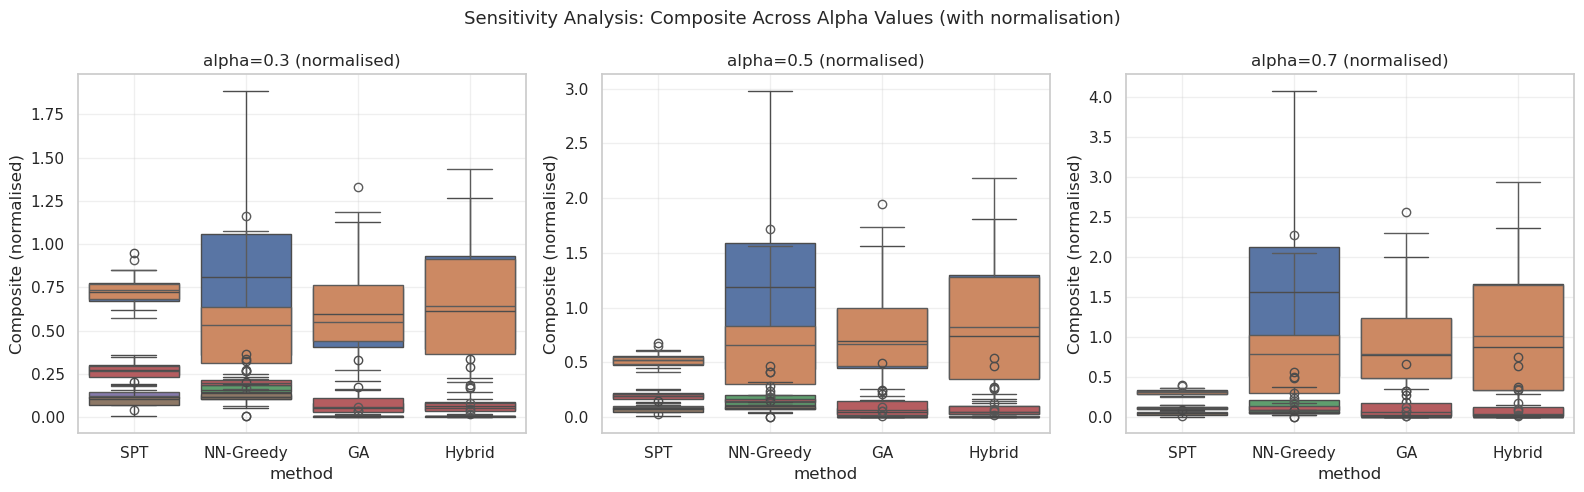

In [7]:
if results_df is not None:
    print("\n=== Sensitivity Analysis: Composite Rescaled Across Alpha ===")
    
    # Estimate scale factors using evaluator.s estimate_scales() (SPT+NN+random × 1.5)
    from src.instance_generator import generate_instance
    inst = generate_instance(n=20, m=3, seed=0, profile="baseline")
    f1_scale, f2_scale = estimate_scales(inst)
    
    print(f"Estimated scale factors (estimate_scales):")
    print(f"  f1_scale (weighted_tardiness): {f1_scale:.2f}")
    print(f"  f2_scale (setup_cost): {f2_scale:.2f}")
    
    # Recompute composite for multiple alpha values
    alphas = [0.3, 0.5, 0.7]
    sensitivity_df = results_df.copy()
    
    for a in alphas:
        normalised_composite = (
            a * (sensitivity_df["weighted_tardiness"] / f1_scale) +
            (1 - a) * (sensitivity_df["setup_cost"] / f2_scale)
        )
        sensitivity_df[f"composite_alpha_{a}"] = normalised_composite
    
    # Summary by alpha
    print("\nMean normalised composite by method and alpha:")
    for a in alphas:
        col = f"composite_alpha_{a}"
        mean_per_method = sensitivity_df.groupby("method")[col].mean().round(3)
        print(f"\nalpha={a}:")
        print(mean_per_method)
    
    # Plot normalised composites
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for ax, a in zip(axes, alphas):
        col = f"composite_alpha_{a}"
        configs = sorted(sensitivity_df["config"].unique())
        for cfg in configs:
            data = sensitivity_df[sensitivity_df["config"] == cfg]
            sns.boxplot(data=data, x="method", y=col, ax=ax)
        ax.set_title(f"alpha={a} (normalised)")
        ax.set_ylabel("Composite (normalised, lower is better)")
        ax.grid(True, alpha=0.3)
    
    fig.suptitle("Sensitivity Analysis: Composite Across Alpha Values (with normalisation) [lower is better]", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(root, "figures/05_sensitivity_alpha.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No data to analyse.")

## 6. Export Results

In [8]:
if results_df is not None:
    # CSV export
    csv_path = os.path.join(root, "results_summary.csv")
    results_df.to_csv(csv_path, index=False)
    print(f"✓ Exported to {csv_path}")
    
    # LaTeX export (per-config summary)
    latex_path = os.path.join(root, "results_summary.tex")
    summary_latex = results_df.groupby(["config", "method"])[["composite", "weighted_tardiness", "setup_cost", "makespan"]].mean()
    with open(latex_path, "w") as f:
        latex_str = summary_latex.round(3).to_latex()
        latex_str = latex_str.replace("\\bottomrule",
            "\\bottomrule\n\\multicolumn{5}{l}{\\small\\textit{Note: Composite score is minimised (lower is better).}}\\\\n")
        f.write(latex_str)
    print(f"✓ Exported to {latex_path}")
    
    # Full results table
    full_latex_path = os.path.join(root, "results_full.tex")
    with open(full_latex_path, "w") as f:
        full_latex = results_df.round(3).to_latex(index=False)
        full_latex = full_latex.replace("\\bottomrule",
            "\\bottomrule\n\\multicolumn{6}{l}{\\small\\textit{Note: Composite score is minimised (lower is better).}}\\\\n")
        f.write(full_latex)
    print(f"✓ Exported to {full_latex_path}")
else:
    print("No data to export.")

✓ Exported to /home/dopedino/Documents/Dissertation/results_summary.csv
✓ Exported to /home/dopedino/Documents/Dissertation/results_summary.tex
✓ Exported to /home/dopedino/Documents/Dissertation/results_full.tex


## Summary

This notebook loads experimental results and produces final figures and statistics:

- Box plots show performance distributions per instance config
- Wilcoxon tests quantify pairwise method differences (with corrected p-values)
- Sensitivity analysis re-evaluates composites with normalisation (alpha in [0.3, 0.5, 0.7])
- Exports provide LaTeX tables for dissertation

Key findings populate Chapter 5 (Evaluation) of the dissertation.